<a href="https://colab.research.google.com/github/suo030250/Generative-AI-Course/blob/main/%E4%BA%A4%E5%A4%A7_314514087_%E5%85%89%E9%9B%BB%E7%B3%BB_%E5%87%BD%E6%95%B8%E5%9C%96%E5%BD%A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 高斯波包：把波浪裝進鐘形曲線:

## 1｜創作概念


我會選擇畫高斯波包，是因為之前在光學與物理相關課程中有看到「波包」的概念。單純的正弦或餘弦波會一直維持固定振幅，但實際上的光脈衝或波動通常不會無限延伸，而是集中在某一個區域。
所以我想利用 Gaussian function 搭配 cosine wave，畫出一個中間振幅較大、往兩側逐漸衰減的波形，也順便觀察不同參數對波形的影響。
## 2｜使用的函數
$$
f(x)=e^{-x^2/(2\sigma^2)}\cos(kx)
$$

其中：

- $\sigma$：控制整個波包的寬度
- $k$：控制波的振盪頻率

這次我設定：

- $\sigma=1.6$
- $k=7$
- $-6 \le x \le 6$

其中 $\sigma$ 會影響波包的寬度，
而 $k$ 會影響波形振盪的密集程度。

我選這組參數是因為畫出來後，
可以很明顯看到中間振幅較大，往左右兩側逐漸縮小。

## 3｜開始繪圖
接下來用 NumPy 產生 x 的資料點，
再利用 Matplotlib 畫出高斯波包。

另外我也把上下包絡線一起畫出來，
比較容易看出波形的振幅是怎麼逐漸變小的。

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

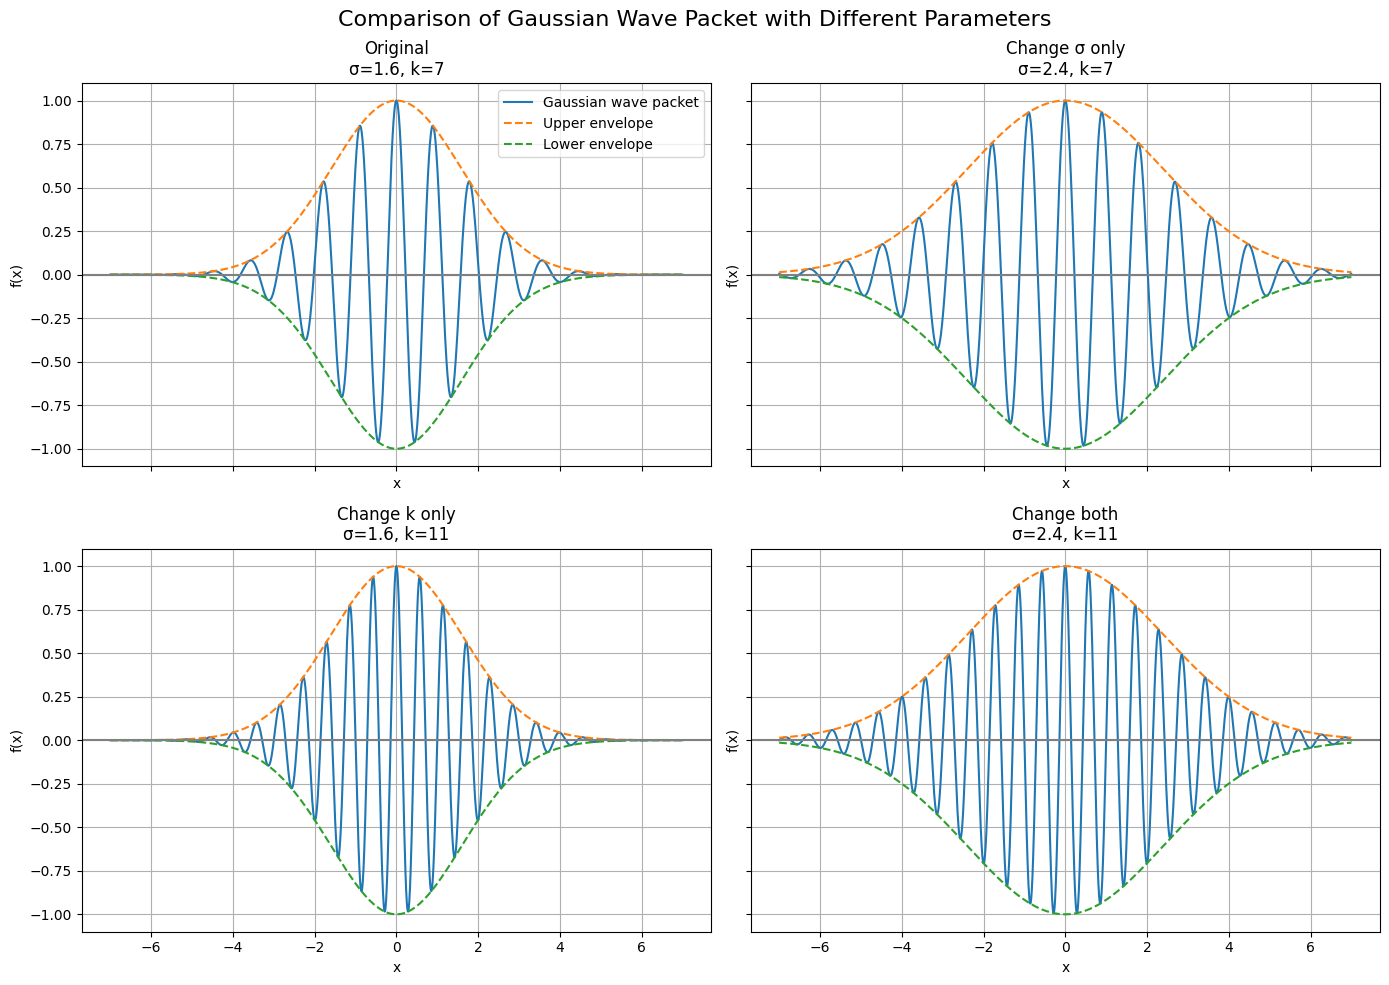

In [ ]:
# 定義函數：把函數定義起來，在比較不同參數時，才能直接使用
def gaussian_wave_packet(x, sigma, k):
    envelope = np.exp(-x**2 / (2 * sigma**2))
    y = envelope * np.cos(k * x)
    return y, envelope

# x 範圍：有試過其他參數-7到7可以看到左右趨近收斂，只取2500點看起來有明顯變化
x = np.linspace(-7, 7, 2500)

# 四組參數
cases = [
    ("Original\nσ=1.6, k=7", 1.6, 7),
    ("Change σ only\nσ=2.4, k=7", 2.4, 7),
    ("Change k only\nσ=1.6, k=11", 1.6, 11),
    ("Change both\nσ=2.4, k=11", 2.4, 11)
]

# 建立四宮格
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten() #用2*2陣列，方便用迴圈

for ax, (title, sigma, k) in zip(axes, cases):
    y, envelope = gaussian_wave_packet(x, sigma, k)

    ax.plot(x, y, label='Gaussian wave packet')
    ax.plot(x, envelope, '--', label='Upper envelope')
    ax.plot(x, -envelope, '--', label='Lower envelope')

    ax.axhline(0, color='gray')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid()

# 只在第一張放圖例，避免太亂
axes[0].legend()

plt.suptitle("Comparison of Gaussian Wave Packet with Different Parameters", fontsize=16)
plt.tight_layout()
plt.show()


## 4｜參數比較

為了更清楚觀察 $\sigma$ 和 $k$ 對高斯波包的影響，我將四組不同參數的結果放在同一張四宮格中比較。

- 左上為原始設定：$\sigma=1.6,\; k=7$
- 右上只改變 $\sigma$：$\sigma=2.4,\; k=7$
- 左下只改變 $k$：$\sigma=1.6,\; k=11$
- 右下則同時改變兩個參數：$\sigma=2.4,\; k=11$

從結果可以看到，當 $\sigma$ 從 1.6 增加到 2.4 時，橘色與綠色的上下包絡線會向左右延伸，因此整個波包變得更寬，波形衰減得比較慢。

當 $k$ 從 7 增加到 11 時，包絡線的寬度幾乎沒有改變，但藍色波形在相同範圍內出現更多次振盪，因此波浪看起來更密集。

最後，同時增加 $\sigma$ 和 $k$ 時，可以同時看到波包變寬以及振盪次數增加的效果。

透過四宮格比較，可以更直接看出：
$\sigma$ 主要控制波包的寬度，而 $k$ 主要控制波形的振盪密度。

**製作工具：** Python、NumPy、Matplotlib。使用生成式 AI 協助設計程式與說明。
